In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error , mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
DATA_PATH = "/content/drive/MyDrive/UCT_Turbofan/data/"

columns = ['unit','cycle']+[f'op{i}' for i in range(1,4)]+[f's{i}' for i in range(1,22)]

train = pd.read_csv(DATA_PATH + "train_FD001.txt", sep=r'\s+', header=None, names=columns )
test = pd.read_csv(DATA_PATH + "test_FD001.txt", sep=r'\s+', header=None, names=columns )
rul = pd.read_csv(DATA_PATH + "RUL_FD001.txt", sep=r'\s+', header=None, names=['RUL'] )

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("RUL shape  :", rul.shape)
train.head()

Train shape: (20631, 26)
Test shape : (13096, 26)
RUL shape  : (100, 1)


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [20]:
# Calculate RUL for training set
max_cycle = train.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns=['unit' , 'max_cycle']
train = train.merge(max_cycle, on='unit', how='left')
train['RUL'] = train['max_cycle'] - train['cycle']
train.drop('max_cycle', axis=1, inplace=True)

# Clip RUL at 125 (common practice)
train['RUL'] = train['RUL'].clip(upper=125)

print(train[['unit', 'cycle', 'RUL']].head(10))

   unit  cycle  RUL
0     1      1  125
1     1      2  125
2     1      3  125
3     1      4  125
4     1      5  125
5     1      6  125
6     1      7  125
7     1      8  125
8     1      9  125
9     1     10  125


In [25]:
# Drop constant / low variance sensors (common in FD001)
drop_cols = ['op3', 's1', 's5', 's10', 's16', 's18', 's19']
train.drop(columns=drop_cols, inplace=True, errors='ignore')
test.drop(columns=drop_cols, inplace=True, errors='ignore')

features = [col for col in train.columns if col not in ['unit', 'cycle', 'RUL']]
print("Selected features:", features)

# Scaling
scaler = MinMaxScaler()
train[features] = scaler.fit_transform(train[features])
test[features]  = scaler.transform(test[features])

Selected features: ['op1', 'op2', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


In [26]:
test_last = test.groupby('unit').last().reset_index()
test_last['RUL'] = rul['RUL'].values
test_last['RUL'] = test_last['RUL'].clip(upper=125)

X_train = train[features]
y_train = train['RUL']
X_test = test_last[features]
y_test = test_last['RUL']

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (20631, 17)
X_test: (100, 17)


In [29]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost:": xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=41, n_jobs=-1)
}

results = {}

for name, model in models.items():
  model.fit(X_train, y_train)
  preds = model.predict(X_test)

  rmse = np.sqrt(mean_squared_error(y_test, preds))
  mae = mean_absolute_error(y_test, preds)
  r2 = r2_score(y_test, preds)

  results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2, "model": model, "preds": preds}
  print(f"{name:20} | RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.3f}")

Random Forest        | RMSE: 77.77 | MAE: 66.67 | R2: -2.766
Gradient Boosting    | RMSE: 63.98 | MAE: 53.69 | R2: -1.549
XGBoost:             | RMSE: 75.18 | MAE: 63.93 | R2: -2.519


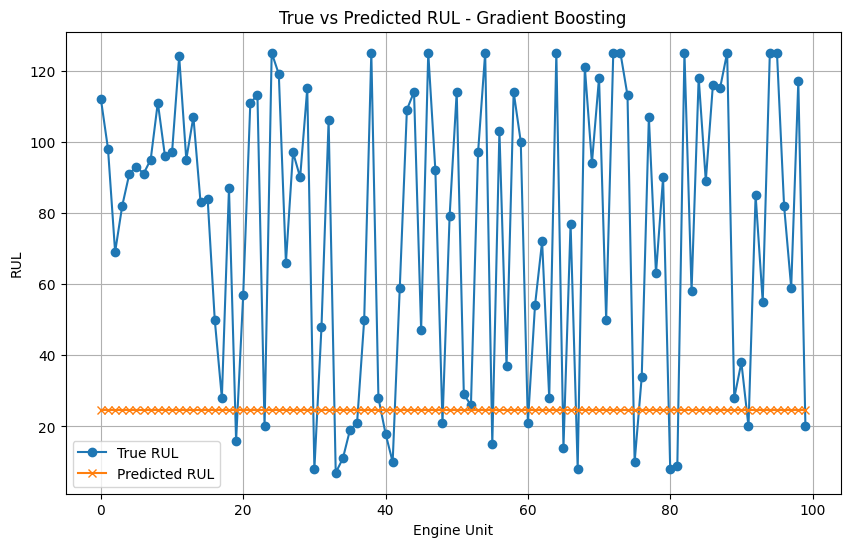

Best model saved as best_rul_model.pkl


In [30]:
best_model_name = min(results, key=lambda x: results[x]["RMSE"])
best_preds = results[best_model_name]["preds"]

plt.figure(figsize=(10,6))
plt.plot(y_test.values, label="True RUL", marker='o')
plt.plot(best_preds, label="Predicted RUL", marker='x')
plt.title(f"True vs Predicted RUL - {best_model_name}")
plt.xlabel("Engine Unit")
plt.ylabel("RUL")
plt.legend()
plt.grid(True)
plt.show()

import joblib
joblib.dump(results[best_model_name]["model"], "best_rul_model.pkl")
print("Best model saved as best_rul_model.pkl")